In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import anndata as ad
import re
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from statsmodels.stats.multitest import multipletests
from scipy.stats import mannwhitneyu

In [2]:
PATH_SIGMA  = "/mnt/projects_tn03/AD_EB_singlecell/article/results_dominguez/merge.h5ad"
PATH_AUTHOR = "/home/lemgui01/raw_STUDIES_thesis/healthy/Dominguez_science_science-abl5197.h5ad"

SEUIL = 0.95

positive_mark = ["GZMK", "GZMB", "NKG7", "PRF1", "CX3CR1", "IL7R", "CD44"]
negative_mark = ["CCR7", "SELL", "TCF7", "LEF1", "CXCR5", "CD27", "FOXP3", "TRDC", "TRGC1", "TRGC2"]

tem_panels = {
    "Positive Tem markers": positive_mark,
    "Negative Tem markers": negative_mark,
}

## 1. Data loading

In [3]:
adata_sigma  = sc.read_h5ad(PATH_SIGMA)
adata_author = sc.read_h5ad(PATH_AUTHOR)

adata_author.X = adata_author.layers["counts"]
adata_sigma.obs_names = adata_sigma.obs_names.str.replace(
    r"-Dominguez_.*?_data$", "", regex=True)

print(f"adata_sigma  : {adata_sigma.shape[0]:,} cells")
print(f"adata_author : {adata_author.shape[0]:,} cells")

adata_sigma  : 41,214 cells
adata_author : 329,762 cells


## 2. Build adata_sumry

In [4]:
adata_sumry = ad.AnnData(adata_author.X)
adata_sumry.obs_names = adata_author.obs_names
adata_sumry.var_names = adata_author.var_names
adata_sumry.obsm["X_umap"] = adata_author.obsm["X_umap"]
adata_sumry.layers["raw"] = adata_author.layers["counts"]
adata_sumry.layers["log1p"] = adata_author.X
adata_sumry.obs["donor"] = adata_author.obs["Donor"]
adata_sumry.obs["sex"] = adata_author.obs["Sex"]
adata_sumry.obs["age"] = adata_author.obs["Age_range"]
adata_sumry.obs["organ"] = adata_author.obs["Organ"]
adata_sumry.obs["assay"] = adata_author.obs["Chemistry"]
adata_sumry.obs["celltype"] = adata_author.obs["Predicted_labels_CellTypist"]

adata_sumry.obs["score"] = 0.0
common_idx = adata_sigma.obs_names.intersection(adata_sumry.obs_names)
adata_sumry.obs.loc[common_idx, "score"] = adata_sigma.obs.loc[common_idx, "score"].values

for prob in [c for c in adata_sigma.obs.columns if c.startswith("proba_")]:
    adata_sumry.obs[prob] = 0.0
    adata_sumry.obs.loc[adata_sigma.obs_names, prob] = adata_sigma.obs[prob].values

sc.pp.normalize_total(adata_sumry, target_sum=1e6)
sc.pp.log1p(adata_sumry)

## 3. SIGMA+ labeling

In [5]:
tem_found_by_sigma = adata_sumry.obs["score"] >= SEUIL
adata_sumry.obs["Identified by SIGMA"] = pd.Categorical(
    tem_found_by_sigma.astype(str), categories=["False", "True"], ordered=True)

sub_adata_sumry = adata_sumry[adata_sumry.obs["Identified by SIGMA"] == "True"]

print(f"# Tem cyto : {np.sum(tem_found_by_sigma):,}")
print(f"% among all cells : {np.sum(tem_found_by_sigma)/adata_sumry.n_obs*100:.3%}")

tem_author = adata_sumry[adata_sumry.obs["celltype"] == "Tem/Effector cytotoxic T cells"]
print(f"% among TEM from authors : {np.sum(tem_found_by_sigma)/tem_author.n_obs:.3%}")

# Tem cyto : 2,698
% among all cells : 81.817%
% among TEM from authors : 27.675%


## 4. Prepare dataframes

In [ ]:
# PCA
sc.pp.pca(sub_adata_sumry, n_comps=10)

# celltype distribution
celltype_counts = (
    sub_adata_sumry.obs['celltype'].value_counts()
    .reset_index(name='count')
    .rename(columns={'index': 'celltype'})
    .sort_values('count', ascending=False)
)
celltype_counts['celltype'] = celltype_counts['celltype'].astype(str)

# organ distribution
organ_counts = (
    sub_adata_sumry.obs['organ'].value_counts()
    .reset_index(name='count')
    .rename(columns={'index': 'organ'})
    .sort_values('count', ascending=False)
)
for org in organ_counts['organ']:
    ncells = adata_sumry.obs['organ'].value_counts().get(org, 0)
    organ_counts.loc[organ_counts['organ'] == org, 'proportion'] = (
        organ_counts.loc[organ_counts['organ'] == org, 'count'].values[0] / ncells * 100
        if ncells > 0 else 0.0
    )
organ_counts = organ_counts.sort_values('proportion', ascending=False).reset_index(drop=True)
organ_counts['organ'] = organ_counts['organ'].astype(str)

color_mapping = {}
fig_tmp, ax_tmp = plt.subplots()
sns.barplot(data=celltype_counts, x='celltype', y='count', hue='celltype',
            palette='tab20', dodge=False, order=celltype_counts['celltype'], ax=ax_tmp)
for patch, celltype in zip(ax_tmp.patches, celltype_counts['celltype']):
    color_mapping[celltype] = patch.get_facecolor()
plt.close(fig_tmp)

# Tem markers dataframes
tem_df = tem_author.to_df()
tem_df["identified"] = tem_author.obs["Identified by SIGMA"].values
tem_df_melt = tem_df.melt(id_vars="identified", var_name="gene", value_name="expression")

def compute_markers(df_melt, panels):
    results = {}
    for panel_name, genes in panels.items():
        df = df_melt.loc[df_melt["gene"].isin(genes), ["gene", "identified", "expression"]].copy()
        df = df.dropna(subset=["expression"])
        df["identified"] = df["identified"].eq("True")
        mannwhit_res = {}
        for gene, sub in df.groupby("gene", sort=False):
            no_ident = sub.loc[~sub["identified"], "expression"].to_numpy()
            ident    = sub.loc[sub["identified"],  "expression"].to_numpy()
            U, p = mannwhitneyu(no_ident, ident,
                                alternative="less" if panel_name == "Positive Tem markers" else "greater")
            mannwhit_res[gene] = (U, p)
        mannwhit_df = (pd.DataFrame.from_dict(mannwhit_res, orient="index", columns=["U_stat", "p_value"])
                       .rename_axis("gene").reset_index())
        mannwhit_df["p_value_adj"] = multipletests(mannwhit_df["p_value"], method="fdr_bh")[1]
        plot_df  = df.assign(identified=df["identified"].map({False: "False", True: "True"}))
        bar_top  = plot_df.groupby(["gene", "identified"])["expression"].mean().groupby("gene").max()
        results[panel_name] = {"genes": genes, "plot_df": plot_df,
                               "mannwhit_df": mannwhit_df, "bar_top": bar_top}
    return results

results_D = compute_markers(tem_df_melt, tem_panels)

/home/lemgui01/.miniconda3/envs/SIGMA/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:379: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca


## 5. Utility functions

In [7]:
def p_to_star(p):
    if p < 0.0001: return "****"
    if p < 0.001:  return "***"
    if p < 0.01:   return "**"
    if p < 0.05:   return "*"
    return ""

def plot_A(ax):
    n, bins, _ = ax.hist(adata_sigma.obs["score"], bins=200, alpha=0.7)
    ax.set_xlabel("Score"); ax.set_ylabel("Number of cells", color='C0')
    ax.set_yscale("log"); ax.tick_params(axis='y', labelcolor='C0')
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax2 = ax.twinx()
    cumsum_pct  = 100 * np.cumsum(n) / np.sum(n)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    ax2.plot(bin_centers, cumsum_pct, color='red', linewidth=2)
    ax2.set_ylabel("Cumulative percentage of cells (%)", color='red')
    ax2.set_ylim(min(cumsum_pct), 100); ax2.tick_params(axis='y', labelcolor='red')
    ax.axvline(SEUIL, color='black', linestyle='--', linewidth=1)
    ax.text(SEUIL-0.085, ax.get_ylim()[1]*0.85, str(SEUIL),
            color='black', ha='left', va='top', fontsize=14)
    ax.set_title("Distribution of SIGMA scores", fontsize=16)
    ax.tick_params(axis="both", labelsize=14); ax2.tick_params(axis="y", labelsize=14)

def plot_B(ax):
    pc_var = sub_adata_sumry.uns['pca']['variance_ratio']
    sc.pl.pca(sub_adata_sumry, s=50, color='celltype',
              palette=color_mapping, legend_loc='none', show=False, ax=ax)
    ax.set_xlabel(f'PC1 ({pc_var[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pc_var[1]*100:.1f}%)')
    ax.set_title('PCA of SIGMA-identified Tem cytotoxic lymphocytes', fontsize=14)

def plot_supp(ax):
    sns.barplot(data=celltype_counts, x='celltype', y='count',
                hue='celltype', palette='tab20', dodge=False,
                order=celltype_counts['celltype'], ax=ax)
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    plt.setp(ax.get_xticklabels(), rotation=90)
    ax.set_ylabel('Number of cells')
    ax.grid(axis='y', linestyle='--')
    ax.set_yscale('log')
    ax.set_ylim(0.5, celltype_counts['count'].max()*1.8)
    ax.set_title("Origin assignments for cells identified by SIGMA as Tem cytotoxic lymphocytes", fontsize=13)

def plot_C(ax):
    sns.barplot(data=organ_counts, x='organ', y='proportion',
                hue='organ', palette='tab20', dodge=False,
                width=0.4, order=organ_counts['organ'].tolist(), ax=ax)
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    ax.set_ylabel('Percentage of Tem cytotoxic cells')
    ax.set_ylim(0, organ_counts['proportion'].max()+3)
    ax.grid(axis='y', linestyle='--')
    ax.set_title("Percentage of SIGMA-identified Tem cytotoxic lymphocytes by organ", fontsize=13)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    for p in ax.patches:
        height = p.get_height()
        if np.isfinite(height) and height > 0:
            ax.text(p.get_x() + p.get_width(), height + 0.001,
                    f'{height:.2f}%', ha='center', va='bottom', fontsize=9)

def plot_D(axes, results):
    for cpt, (panel_name, r) in enumerate(results.items()):
        ax = axes[cpt]
        sns.barplot(data=r["plot_df"], x="gene", y="expression", hue="identified",
                    order=r["genes"], ax=ax, palette={"False": "red", "True": "green"})
        for i, gene in enumerate(r["genes"]):
            pval = r["mannwhit_df"].loc[r["mannwhit_df"]["gene"] == gene, "p_value_adj"].values
            y0   = float(r["bar_top"].loc[gene])
            ax.text(i, y0 + 0.01*y0, p_to_star(pval), ha="center", va="bottom", fontsize=14)
        ax.set_ylim(0, ax.get_ylim()[1]+1); ax.set_xlabel(None)
        ax.set_title(panel_name, fontsize=16)
        ax.tick_params(axis="y", labelsize=14)
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=14)
        ax.legend(title="Tem identified by SIGMA",
                  loc="upper center", ncol=2, fontsize=14, title_fontsize=12)

## 6. Figure A - Score distribution

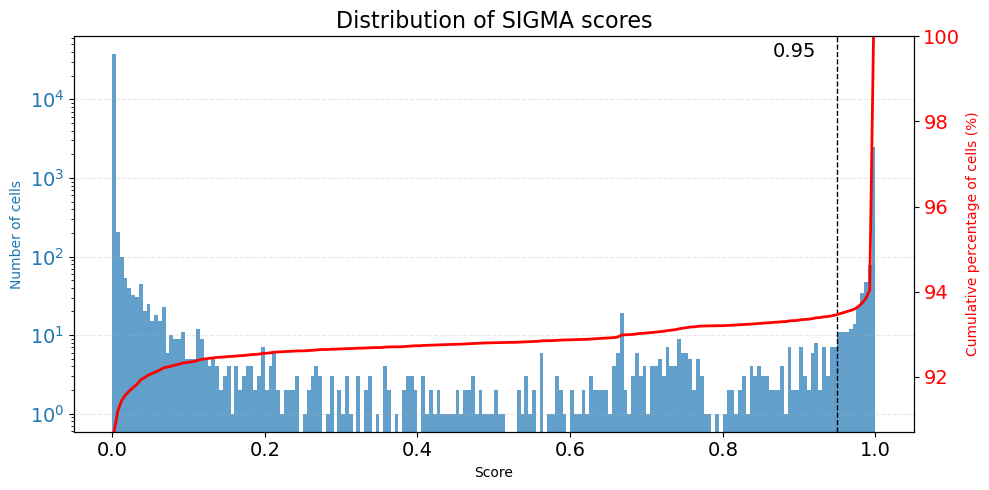

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_A(ax)
fig.tight_layout()
# fig.savefig("figures/dominguez_A.svg", bbox_inches="tight", dpi=300)
fig.savefig("figures/dominguez_A.pdf", bbox_inches="tight", dpi=300)
plt.show()

## 7. Figure B - PCA

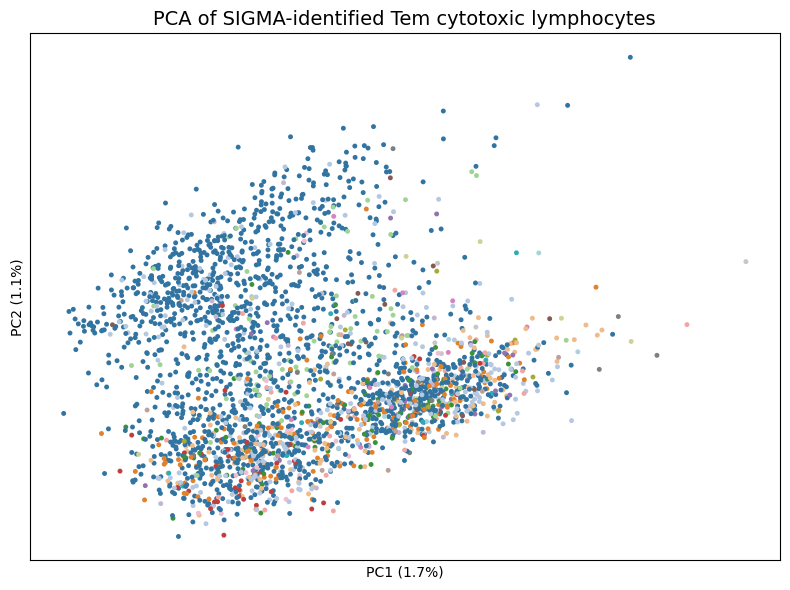

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
plot_B(ax)
fig.tight_layout()
# fig.savefig("figures/dominguez-B.tiff", bbox_inches="tight", dpi=300)
fig.savefig("figures/dominguez-B.pdf", bbox_inches="tight", dpi=300)
plt.show()

## 8. Figure C - Organ distribution

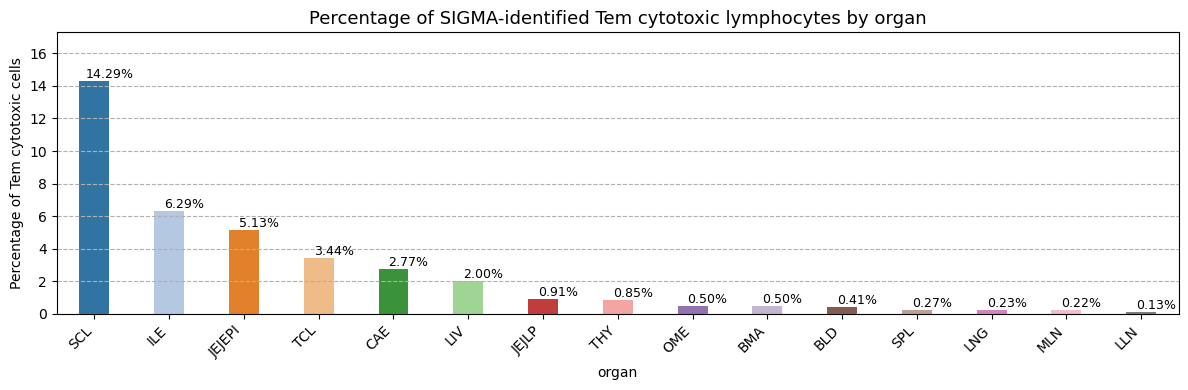

In [12]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_C(ax)
fig.tight_layout()
# fig.savefig("figures/dominguez-C.svg", bbox_inches="tight", dpi=300)
fig.savefig("figures/dominguez-C.pdf", bbox_inches="tight", dpi=300)
plt.show()

## 9. Figure D - Tem markers

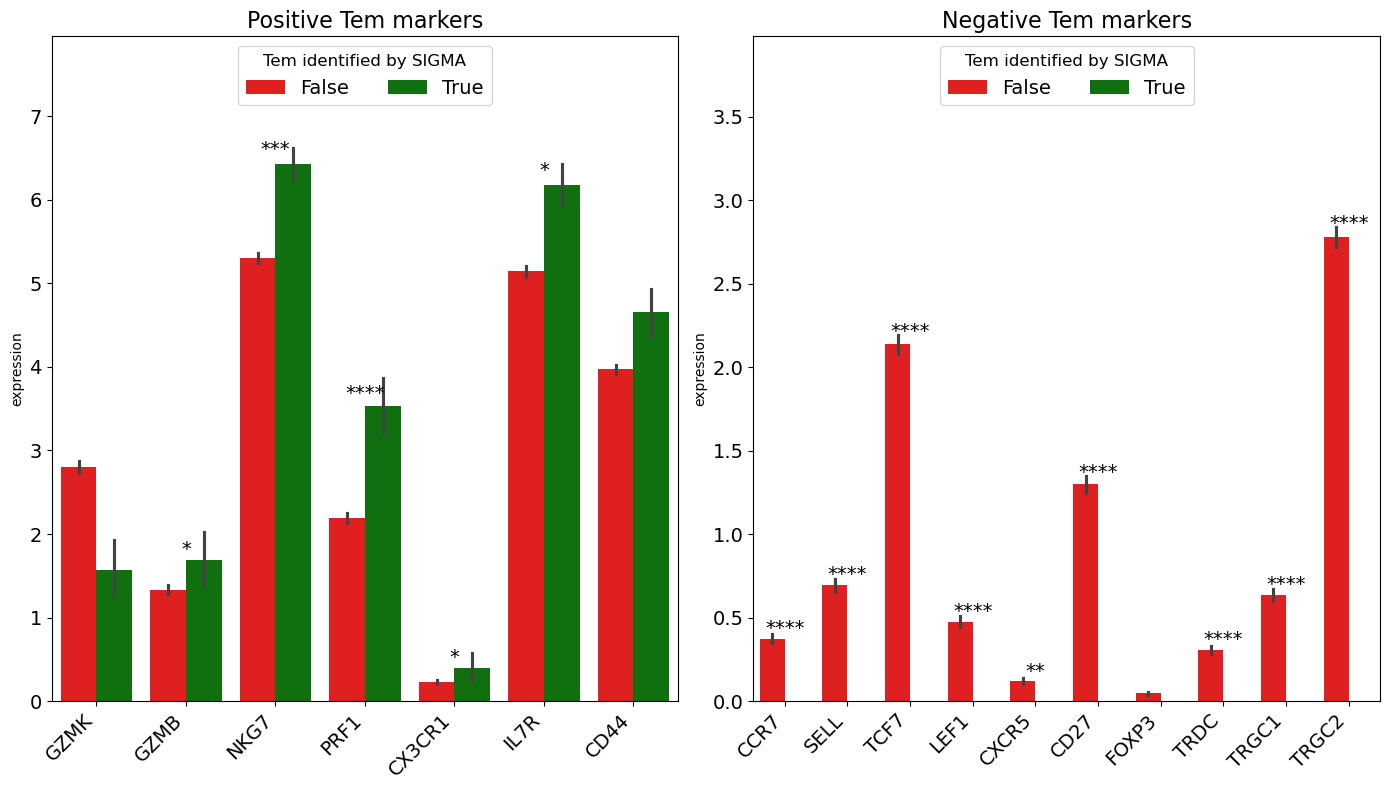

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(14, 8))
plot_D(ax, results_D)
fig.tight_layout()
# fig.savefig("figures/dominguez-D.svg", bbox_inches="tight", dpi=300)
fig.savefig("figures/dominguez-D.pdf", bbox_inches="tight", dpi=300)
plt.show()

## 10. Final figure

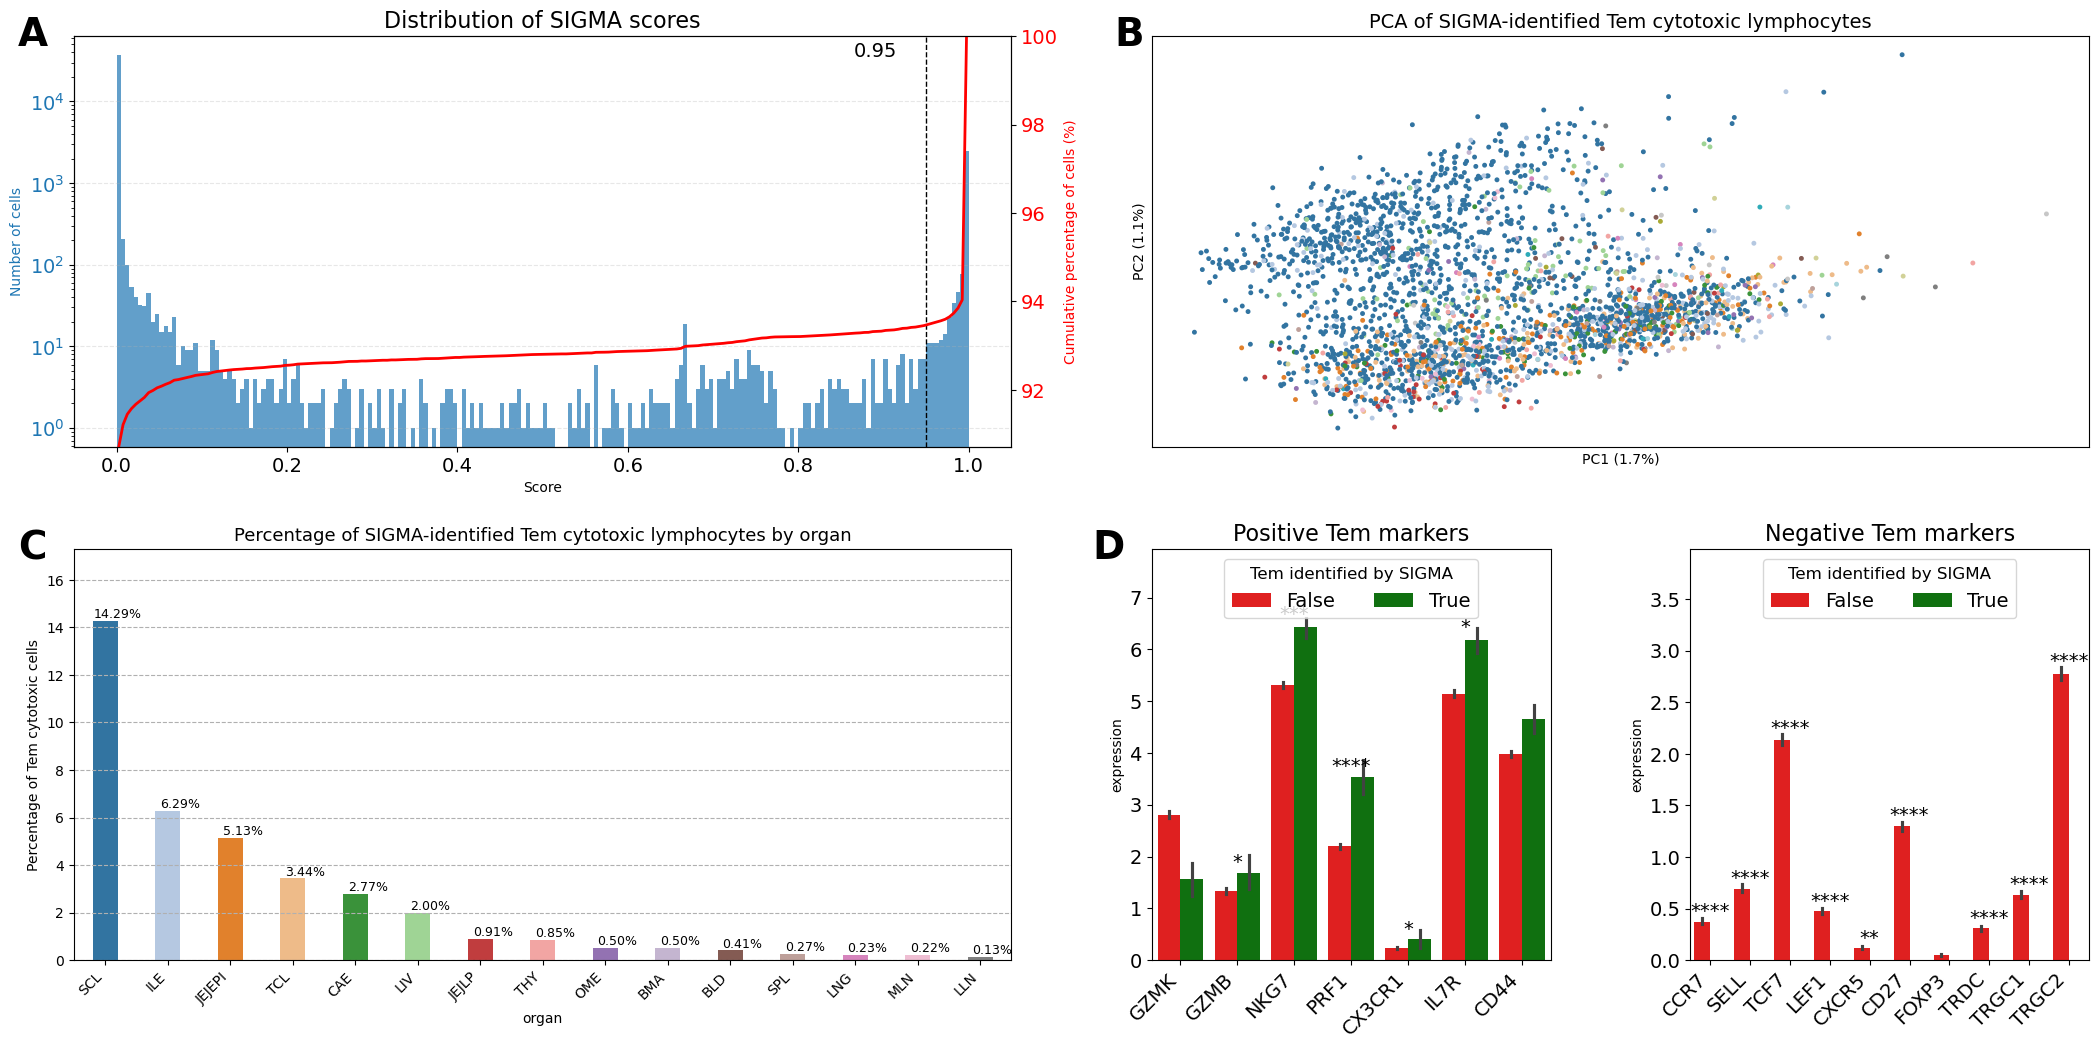

In [14]:
fig = plt.figure(figsize=(26, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.25, wspace=0.15, height_ratios=[1, 1])

ax_A  = fig.add_subplot(gs[0, 0])
ax_B  = fig.add_subplot(gs[0, 1])
ax_C  = fig.add_subplot(gs[1, 0])
gs_D  = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[1, 1], wspace=0.35)
ax_Ds = [fig.add_subplot(gs_D[i]) for i in range(2)]

plot_A(ax_A)
plot_B(ax_B)
plot_C(ax_C)
plot_D(ax_Ds, results_D)

ax_A.text(-0.06, 1.05, "A", transform=ax_A.transAxes, fontsize=28, fontweight="bold", va="top")
ax_B.text(-0.04, 1.05, "B", transform=ax_B.transAxes, fontsize=28, fontweight="bold", va="top")
ax_C.text(-0.06, 1.05, "C", transform=ax_C.transAxes, fontsize=28, fontweight="bold", va="top")
ax_Ds[0].text(-0.15, 1.05, "D", transform=ax_Ds[0].transAxes, fontsize=28, fontweight="bold", va="top")

# fig.savefig("figures/dominguez-full.svg", bbox_inches="tight", dpi=300)
fig.savefig("figures/dominguez-full.pdf", bbox_inches="tight", dpi=300)
plt.show()

## 11. Supplemental

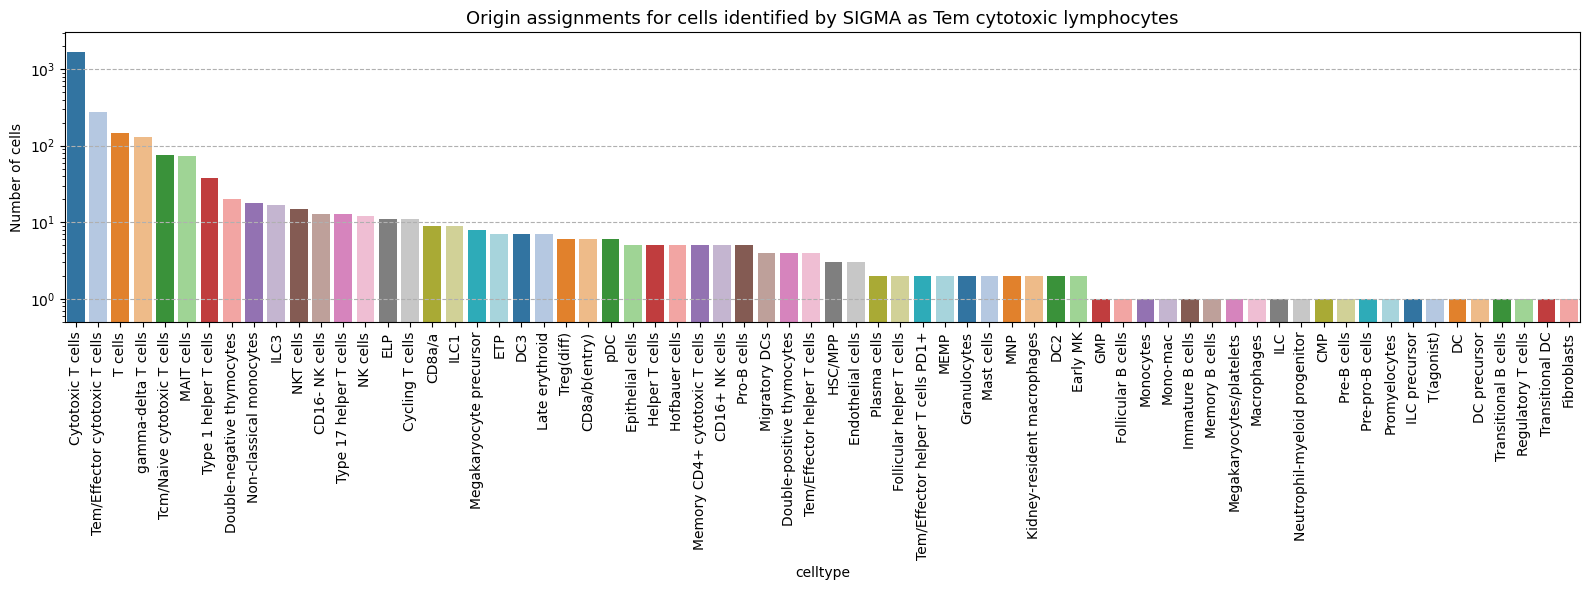

In [15]:
fig, ax = plt.subplots(figsize=(16, 6))
plot_supp(ax)
fig.tight_layout()
# fig.savefig("figures/dominguez_SUP.svg", bbox_inches="tight", dpi=300)
fig.savefig("figures/dominguez_SUP.pdf", bbox_inches="tight", dpi=300)
plt.show()